# Spotify Project — Data Cleaning & Processing

This notebook documents the cleaning of four raw Spotify data files and
produces a set of clean, analysis-ready CSVs plus a harmonized, merged
song-level dataset. Every issue found in the raw data is diagnosed with code
*before* it's fixed, so each decision is auditable.

**Inputs** (place alongside this notebook, or edit `RAW_DIR` below):
- `Spotify_Project_spotify-2023.csv` — 953 tracks, 2023 Spotify chart snapshot
- `Spotify_Project_spotify_alltime_top100_songs.csv` — all-time top 100 streamed songs
- `Spotify_Project_spotify_wrapped_2025_top50_artists.csv` — 2025 Wrapped top 50 artists
- `Spotify_Project_spotify_wrapped_2025_top50_songs.csv` — 2025 Wrapped top 50 songs

**Outputs** (written to `OUT_DIR`):
- `clean_spotify2023.csv`, `clean_alltime_top100_songs.csv`,
  `clean_wrapped_2025_top50_artists.csv`, `clean_wrapped_2025_top50_songs.csv`
- `merged_songs_harmonized.csv` — the three song-level files stacked into one
  common schema, with audio features rescaled to 0–1


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")

RAW_DIR = "./"   # folder containing the raw Spotify_Project_*.csv files
OUT_DIR = "./"   # folder to write cleaned files to


## 1. `spotify-2023.csv` — 2023 Spotify chart snapshot

This is the messiest of the four files. We load it and inspect it before
touching anything.


In [2]:
df = pd.read_csv(RAW_DIR + "Spotify_Project_spotify-2023.csv", encoding="latin1")
print(df.shape)
df.dtypes


(953, 24)


track_name                str
artist(s)_name            str
artist_count            int64
released_year           int64
released_month          int64
released_day            int64
in_spotify_playlists    int64
in_spotify_charts       int64
streams                   str
in_apple_playlists      int64
in_apple_charts         int64
in_deezer_playlists       str
in_deezer_charts        int64
in_shazam_charts          str
bpm                     int64
key                       str
mode                      str
danceability_%          int64
valence_%               int64
energy_%                int64
acousticness_%          int64
instrumentalness_%      int64
liveness_%              int64
speechiness_%           int64
dtype: object

**Issue 1 — Encoding.** The file isn't valid UTF-8 — it has to be read with
`latin1` or it throws a `UnicodeDecodeError`. That leaves mojibake in accented
artist/track names (e.g. an "í" rendered as `ï¿½`). We'll re-encode the text
columns to clean up what we can.


In [3]:
mojibake = df[df["track_name"].str.contains("\ufffd|ï¿½", na=False, regex=True)]
print(f"{len(mojibake)} track names contain visible mojibake, e.g.:")
mojibake["track_name"].head()


58 track names contain visible mojibake, e.g.:


21    I Can See You (Taylorï¿½ï¿½ï¿½s Version) (From...
36                       Frï¿½ï¿½gil (feat. Grupo Front
60                                               Tï¿½ï¿
79                                      CORAZï¿½ï¿½N VA
82                                    Novidade na ï¿½ï¿
Name: track_name, dtype: str

**Issue 2 — A corrupted `streams` value.** Several numeric-looking columns
(`streams`, `in_deezer_playlists`, `in_shazam_charts`) loaded as text, not
numbers. Let's find exactly which rows fail to parse as plain integers.


In [4]:
def isnum(x):
    try:
        float(str(x).replace(",", ""))
        return True
    except ValueError:
        return False

bad_streams = df[~df["streams"].apply(isnum)]
bad_streams[["track_name", "artist(s)_name", "streams"]]


,track_name,artist(s)_name,streams
574,Love Grows (Where My Rosemary Goes),Edison Lighthouse,BPM110KeyAModeMajorDanceability53Valence75Ener...


One row's `streams` field contains a garbled string
(`"BPM110KeyAModeMajorDanceability53..."`) instead of a play count — a known
artifact in this dataset. The rest of that row's data (bpm, key, mode,
danceability, etc.) is intact and valid, so we set just that one cell to
`NaN` rather than dropping the whole record.


In [5]:
bad_streams_mask = ~df["streams"].apply(isnum)
n_bad = bad_streams_mask.sum()
df.loc[bad_streams_mask, "streams"] = np.nan
print(f"Corrected {n_bad} corrupted streams value(s).")


Corrected 1 corrupted streams value(s).


**Issue 3 — Thousands-separator commas.** `streams`, `in_deezer_playlists`,
and `in_shazam_charts` contain values like `"2,445"`, which pandas reads as
text. Strip the commas and cast to numeric.


In [6]:
for col in ["streams", "in_deezer_playlists", "in_shazam_charts"]:
    df[col] = (
        df[col].astype(str)
        .str.replace(",", "", regex=False)
        .replace("nan", np.nan)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[["streams", "in_deezer_playlists", "in_shazam_charts"]].dtypes


streams                float64
in_deezer_playlists      int64
in_shazam_charts       float64
dtype: object

In [7]:
# Clean up the mojibake in name fields as best we can
for col in ["track_name", "artist(s)_name"]:
    df[col] = (
        df[col]
        .str.encode("latin1", errors="ignore")
        .str.decode("utf-8", errors="ignore")
        .fillna(df[col])
    )

# Standardize column names (drop % signs, expand abbreviations)
df = df.rename(columns={
    "artist(s)_name": "artist_name",
    "danceability_%": "danceability_pct",
    "valence_%": "valence_pct",
    "energy_%": "energy_pct",
    "acousticness_%": "acousticness_pct",
    "instrumentalness_%": "instrumentalness_pct",
    "liveness_%": "liveness_pct",
    "speechiness_%": "speechiness_pct",
})
df.columns.tolist()


['track_name',
 'artist_name',
 'artist_count',
 'released_year',
 'released_month',
 'released_day',
 'in_spotify_playlists',
 'in_spotify_charts',
 'streams',
 'in_apple_playlists',
 'in_apple_charts',
 'in_deezer_playlists',
 'in_deezer_charts',
 'in_shazam_charts',
 'bpm',
 'key',
 'mode',
 'danceability_pct',
 'valence_pct',
 'energy_pct',
 'acousticness_pct',
 'instrumentalness_pct',
 'liveness_pct',
 'speechiness_pct']

**Issue 4 — Split date fields.** `released_year`/`released_month`/`released_day`
are three separate integer columns. Combine them into one proper date, and
check for any that don't form a valid calendar date.


In [8]:
df["release_date"] = pd.to_datetime(
    dict(year=df["released_year"], month=df["released_month"], day=df["released_day"]),
    errors="coerce",
)
n_bad_dates = df["release_date"].isna().sum()
print(f"{n_bad_dates} rows produced an invalid date.")


0 rows produced an invalid date.


**Issue 5 — Missing values.** Check every column for missing data before
deciding how (or whether) to handle it.


In [9]:
df.isna().sum()[df.isna().sum() > 0]


streams              1
in_shazam_charts    50
key                 95
dtype: int64

- `key` is missing for ~10% of tracks. This is a categorical musical key —
  there's no principled way to impute it, so we leave it as `NaN` and add a
  `key_missing` flag in case "key not detected" is itself informative.
- `in_shazam_charts` is missing for a smaller set of tracks. A missing Shazam
  chart entry plausibly means the track simply never charted there (a true
  zero), not an unknown value — so we fill it with 0 and add an
  `shazam_charts_imputed` flag so that assumption stays visible and reversible.


In [10]:
df["key_missing"] = df["key"].isna()

df["shazam_charts_imputed"] = df["in_shazam_charts"].isna()
df["in_shazam_charts"] = df["in_shazam_charts"].fillna(0)


**Issue 6 — Duplicate records.** Check for repeated (track, artist) pairs.


In [11]:
dup_mask = df.duplicated(subset=["track_name", "artist_name"], keep=False)
print(f"{dup_mask.sum()} rows involved in a duplicate (track, artist) pair.")
df.loc[dup_mask, ["track_name", "artist_name", "streams", "released_year"]].sort_values("track_name")


8 rows involved in a duplicate (track, artist) pair.


,track_name,artist_name,streams,released_year
372,About Damn Time,Lizzo,723894473.0,2022
764,About Damn Time,Lizzo,723894473.0,2022
178,SNAP,Rosa Linn,726307468.0,2022
873,SNAP,Rosa Linn,711366595.0,2022
345,SPIT IN MY FACE!,ThxSoMch,303216294.0,2022
482,SPIT IN MY FACE!,ThxSoMch,301869854.0,2022
512,Take My Breath,The Weeknd,130655803.0,2021
616,Take My Breath,The Weeknd,432702334.0,2021


These are genuine repeated entries (e.g. "SNAP" by Rosa Linn appears twice)
but with **different** stream counts each time — most likely two different
chart-snapshot dates for the same song. We keep both rows rather than
dropping one arbitrarily, since each carries distinct information; a
`duplicated()` mask is left available for anyone who wants to de-duplicate
further downstream.


In [12]:
spotify2023_clean = df.copy()
spotify2023_clean.to_csv(OUT_DIR + "clean_spotify2023.csv", index=False)
print(f"Saved clean_spotify2023.csv: {spotify2023_clean.shape}")
spotify2023_clean.head()


Saved clean_spotify2023.csv: (953, 27)


,track_name,artist_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_pct,valence_pct,energy_pct,acousticness_pct,instrumentalness_pct,liveness_pct,speechiness_pct,release_date,key_missing,shazam_charts_imputed
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,263,45,10,826.0,125,B,Major,80,89,83,31,0,8,4,2023-07-14,False,False
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,126,58,14,382.0,92,C#,Major,71,61,74,7,0,10,4,2023-03-23,False,False
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,207,91,14,949.0,138,F,Major,51,32,53,17,0,31,6,2023-06-30,False,False
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,207,125,12,548.0,170,A,Major,55,58,72,11,0,11,15,2019-08-23,False,False
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322.0,84,133,87,15,425.0,144,A,Minor,65,23,80,14,63,11,6,2023-05-18,False,False


## 2. `spotify_alltime_top100_songs.csv`

Check this file the same way before assuming it's clean.


In [13]:
alltime = pd.read_csv(RAW_DIR + "Spotify_Project_spotify_alltime_top100_songs.csv")
print(alltime.shape)
print(alltime.isna().sum().sum(), "missing values")
print(alltime.duplicated().sum(), "duplicate rows")
alltime.dtypes


(100, 14)
0 missing values
0 duplicate rows


alltime_rank                int64
song_title                    str
artist                        str
total_streams_billions    float64
primary_genre                 str
bpm                         int64
release_year                int64
artist_country                str
explicit                     bool
danceability              float64
energy                    float64
valence                   float64
acousticness              float64
dataset_part                  str
dtype: object

No missing values, no duplicates, and dtypes are correct on load — nothing to fix.

In [14]:
alltime.to_csv(OUT_DIR + "clean_alltime_top100_songs.csv", index=False)
alltime.head()


,alltime_rank,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
0,1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00,Spotify All-Time Most Streamed Top 100
1,2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08,Spotify All-Time Most Streamed Top 100
2,3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29,Spotify All-Time Most Streamed Top 100
3,4,Sunflower,Post Malone & Swae Lee,3.98,Hip-Hop/Pop,93,2018,USA,False,0.76,0.49,0.84,0.15,Spotify All-Time Most Streamed Top 100
4,5,One Dance,Drake,3.92,Afrobeats/Pop,100,2016,Canada,False,0.79,0.62,0.68,0.09,Spotify All-Time Most Streamed Top 100


## 3. `spotify_wrapped_2025_top50_artists.csv`


In [15]:
wartists = pd.read_csv(RAW_DIR + "Spotify_Project_spotify_wrapped_2025_top50_artists.csv")
print(wartists.shape)
print(wartists.isna().sum().sum(), "missing values")
print(wartists.duplicated().sum(), "duplicate rows")
wartists.dtypes


(50, 11)
0 missing values
0 duplicate rows


wrapped_2025_rank                       int64
artist_name                               str
monthly_listeners_millions_mar2026    float64
primary_genre                             str
country                                   str
followers_millions                      int64
grammy_wins                             int64
debut_year                              int64
gender                                    str
top_2025_song                             str
dataset_part                              str
dtype: object

Also clean out of the box.

In [16]:
wartists.to_csv(OUT_DIR + "clean_wrapped_2025_top50_artists.csv", index=False)
wartists.head()


,wrapped_2025_rank,artist_name,monthly_listeners_millions_mar2026,primary_genre,country,followers_millions,grammy_wins,debut_year,gender,top_2025_song,dataset_part
0,1,The Weeknd,110.4,R&B/Pop,Canada,112,4,2010,Male,Die With A Smile,Spotify Wrapped 2025 Top 50 Artists
1,2,Taylor Swift,107.5,Pop/Country,USA,110,14,2006,Female,Fortnight,Spotify Wrapped 2025 Top 50 Artists
2,3,Drake,88.6,Hip-Hop,Canada,95,4,2006,Male,Amen,Spotify Wrapped 2025 Top 50 Artists
3,4,Bad Bunny,84.2,Reggaeton,Puerto Rico,89,0,2016,Male,NUEVAYoL,Spotify Wrapped 2025 Top 50 Artists
4,5,Sabrina Carpenter,82.1,Pop,USA,58,0,2015,Female,Espresso,Spotify Wrapped 2025 Top 50 Artists


## 4. `spotify_wrapped_2025_top50_songs.csv`


In [17]:
wsongs = pd.read_csv(RAW_DIR + "Spotify_Project_spotify_wrapped_2025_top50_songs.csv")
print(wsongs.shape)
print(wsongs.isna().sum().sum(), "missing values")
print(wsongs.duplicated().sum(), "duplicate rows")
wsongs.dtypes


(50, 16)
0 missing values
0 duplicate rows


wrapped_2025_rank               int64
song_title                        str
artist                            str
streams_2025_billions         float64
primary_genre                     str
bpm                             int64
duration_seconds                int64
release_year                    int64
artist_country                    str
explicit                         bool
danceability                  float64
energy                        float64
valence                       float64
acousticness                  float64
peak_global_chart_position      int64
dataset_part                      str
dtype: object

Also clean out of the box.

In [18]:
wsongs.to_csv(OUT_DIR + "clean_wrapped_2025_top50_songs.csv", index=False)
wsongs.head()


,wrapped_2025_rank,song_title,artist,streams_2025_billions,primary_genre,bpm,duration_seconds,release_year,artist_country,explicit,danceability,energy,valence,acousticness,peak_global_chart_position,dataset_part
0,1,Die With A Smile,Lady Gaga & Bruno Mars,1.70,Pop,120,251,2024,USA,False,0.72,0.68,0.55,0.18,1,Spotify Wrapped 2025 Top 50 Global Songs
1,2,APT.,ROSE & Bruno Mars,1.62,K-Pop/Pop,145,173,2024,South Korea,False,0.86,0.79,0.88,0.05,1,Spotify Wrapped 2025 Top 50 Global Songs
2,3,Espresso,Sabrina Carpenter,1.55,Pop,104,175,2024,USA,False,0.80,0.73,0.96,0.06,1,Spotify Wrapped 2025 Top 50 Global Songs
3,4,Please Please Please,Sabrina Carpenter,1.48,Pop,107,186,2024,USA,False,0.70,0.66,0.87,0.10,1,Spotify Wrapped 2025 Top 50 Global Songs
4,5,Taste,Sabrina Carpenter,1.41,Pop,117,177,2024,USA,True,0.78,0.70,0.82,0.08,1,Spotify Wrapped 2025 Top 50 Global Songs


## 5. Harmonizing the three song-level files into one dataset

`spotify2023`, `alltime_top100`, and `wrapped2025_songs` all describe
individual songs, but on different scales and with different column names:

- `spotify2023`'s audio features (`danceability_pct`, `energy_pct`, etc.) are
  0–100 integer percentages.
- `alltime_top100` and `wrapped2025_songs` use 0–1 floats for the same
  concepts.

To combine them into one dataset, we rescale `spotify2023`'s features to
0–1 and select a common set of columns from each source.


In [19]:
a = spotify2023_clean.rename(columns={"artist_name": "artist", "track_name": "song_title"}).copy()
a["source"] = "spotify2023"
a["danceability"] = a["danceability_pct"] / 100
a["energy"] = a["energy_pct"] / 100
a["valence"] = a["valence_pct"] / 100
a["acousticness"] = a["acousticness_pct"] / 100
a["streams_billions"] = a["streams"] / 1e9
a["genre"] = np.nan  # not present in this source
a_keep = a[["song_title", "artist", "source", "release_date", "released_year",
            "bpm", "danceability", "energy", "valence", "acousticness",
            "streams_billions", "genre"]].rename(columns={"released_year": "release_year"})

b = alltime.rename(columns={"primary_genre": "genre"}).copy()
b["source"] = "alltime_top100"
b_keep = b[["song_title", "artist", "source", "release_year", "bpm",
            "danceability", "energy", "valence", "acousticness",
            "total_streams_billions", "genre"]].rename(columns={"total_streams_billions": "streams_billions"})

c = wsongs.rename(columns={"primary_genre": "genre"}).copy()
c["source"] = "wrapped2025_songs"
c_keep = c[["song_title", "artist", "source", "release_year", "bpm",
            "danceability", "energy", "valence", "acousticness",
            "streams_2025_billions", "genre"]].rename(columns={"streams_2025_billions": "streams_billions"})

merged = pd.concat([a_keep, b_keep, c_keep], ignore_index=True, sort=False)
print(merged.shape)
merged.head()


(1103, 12)


,song_title,artist,source,release_date,release_year,bpm,danceability,energy,valence,acousticness,streams_billions,genre
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",spotify2023,2023-07-14,2023,125,0.80,0.83,0.89,0.31,0.141382,NaN
1,LALA,Myke Towers,spotify2023,2023-03-23,2023,92,0.71,0.74,0.61,0.07,0.133716,NaN
2,vampire,Olivia Rodrigo,spotify2023,2023-06-30,2023,138,0.51,0.53,0.32,0.17,0.140004,NaN
3,Cruel Summer,Taylor Swift,spotify2023,2019-08-23,2019,170,0.55,0.72,0.58,0.11,0.800841,NaN
4,WHERE SHE GOES,Bad Bunny,spotify2023,2023-05-18,2023,144,0.65,0.80,0.23,0.14,0.303236,NaN


Finally, flag songs that appear in more than one source file (e.g. a 2023
hit that's *also* an all-time top-100 song). These rows are **kept**, not
deduplicated away — each source's streams/rank figures differ, and having
the same song observed across eras/sources can itself be a useful signal.


In [20]:
dup_mask = merged.duplicated(subset=["song_title", "artist"], keep=False)
merged["appears_in_multiple_sources"] = dup_mask

n_overlap_songs = merged.loc[dup_mask, ["song_title", "artist"]].drop_duplicates().shape[0]
print(f"{n_overlap_songs} unique songs appear in more than one source file, e.g.:")
merged.loc[dup_mask, ["song_title", "artist", "source"]].drop_duplicates(subset=["song_title", "artist"]).head(10)


56 unique songs appear in more than one source file, e.g.:


,song_title,artist,source
3,Cruel Summer,Taylor Swift,spotify2023
12,Flowers,Miley Cyrus,spotify2023
14,As It Was,Harry Styles,spotify2023
33,Anti-Hero,Taylor Swift,spotify2023
47,Die For You,The Weeknd,spotify2023
55,Blinding Lights,The Weeknd,spotify2023
71,Heat Waves,Glass Animals,spotify2023
72,golden hour,JVKE,spotify2023
73,Sweater Weather,The Neighbourhood,spotify2023
80,Riptide,Vance Joy,spotify2023


In [21]:
merged.to_csv(OUT_DIR + "merged_songs_harmonized.csv", index=False)
print(f"Saved merged_songs_harmonized.csv: {merged.shape}")


Saved merged_songs_harmonized.csv: (1103, 13)


## 6. Quick look at the cleaned data

A few sanity-check plots on the harmonized dataset before moving on to
modeling — not a full EDA, just confirming the cleaning didn't distort
anything.


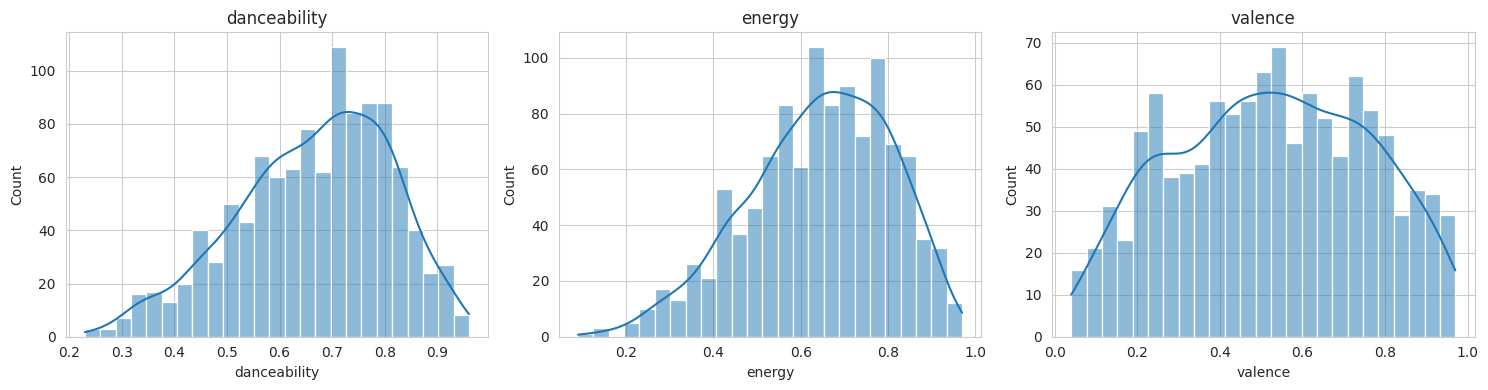

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["danceability", "energy", "valence"]):
    sns.histplot(merged[col].dropna(), bins=25, ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()


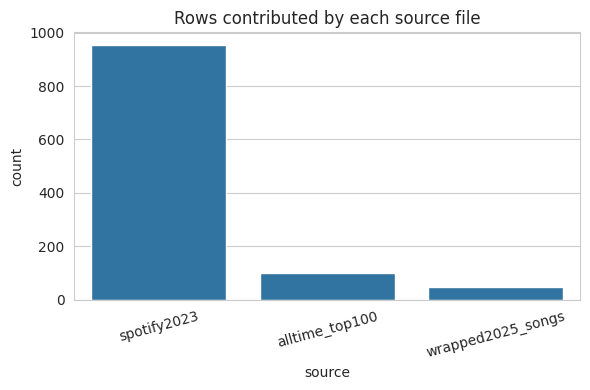

In [23]:
plt.figure(figsize=(6, 4))
sns.countplot(data=merged, x="source", order=merged["source"].value_counts().index)
plt.title("Rows contributed by each source file")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


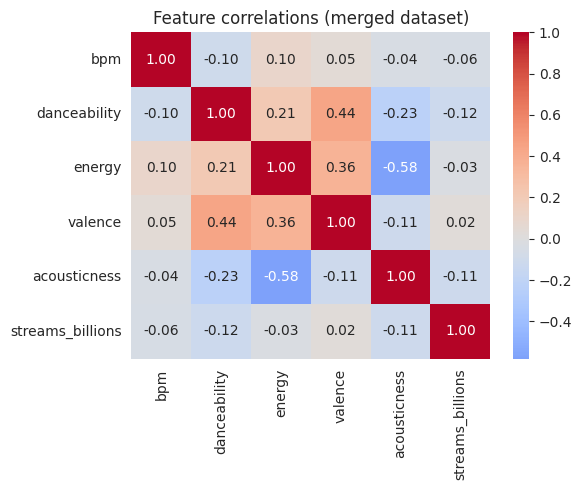

In [24]:
feature_cols = ["bpm", "danceability", "energy", "valence", "acousticness", "streams_billions"]
plt.figure(figsize=(6, 5))
sns.heatmap(merged[feature_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlations (merged dataset)")
plt.tight_layout()
plt.show()


## Summary

| File | Rows | Issues found | Fix applied |
|---|---|---|---|
| `spotify-2023.csv` | 953 | Non-UTF-8 encoding; 1 corrupted `streams` value; 3 numeric columns stored as text; missing `key` (10%) and `in_shazam_charts` (~5%); 4 duplicate (track, artist) pairs with differing stream counts | Re-encoded text; nulled the corrupted cell; cast to numeric; flagged `key_missing`, imputed `in_shazam_charts` with 0 and flagged it; kept duplicates as separate observations |
| `spotify_alltime_top100_songs.csv` | 100 | None | Passed through unchanged |
| `spotify_wrapped_2025_top50_artists.csv` | 50 | None | Passed through unchanged |
| `spotify_wrapped_2025_top50_songs.csv` | 50 | None | Passed through unchanged |
| **Merged** | 1,103 | Inconsistent feature scales (0–100 vs 0–1) and column names across sources | Rescaled to 0–1; renamed to a common schema; flagged 56 songs shared across sources rather than dropping them |

All five output files are saved to `OUT_DIR`.
